# Data Preprocessing

## Import Libraries

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import scipy.stats

## Read the Data

In [51]:
client_train = pd.read_csv('data/client_train.csv', low_memory=False)
invoice_train = pd.read_csv('data/invoice_train.csv', low_memory=False)

client_test = pd.read_csv(f'data/client_test.csv', low_memory=False)
invoice_test = pd.read_csv(f'data/invoice_test.csv', low_memory=False)
sample_submission = pd.read_csv(f'results/SampleSubmission.csv', low_memory=False)

In [52]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


## Data Cleaning

In [53]:
train = invoice_train.copy()
# counter_statue == 269375 -> can be droped, since there is just one observation and also the train_Client_53725 belong to only that observation 
train = train.query("counter_statue != 269375")
# counter_statue == 420 and reading_remarque == 5 and counter_code == 1 -> they are just one time in the same observation, so we can drop them as well
train = train.query("counter_statue != 420")
# replace string of int to int
train['counter_statue'] = train['counter_statue'].replace('0', 0)
train['counter_statue'] = train['counter_statue'].replace('1', 1)
train['counter_statue'] = train['counter_statue'].replace('4', 4)
train['counter_statue'] = train['counter_statue'].replace('5', 5)
# counter_statue == 769 and reading_remarque == 207 ???
train = train.query("counter_statue != 769")
# counter_statue == 618 and reading_remarque == 413 ???
train = train.query("counter_statue != 618")
# counter_statue == 46 and reading_remarque == 203 ???
train = train.query("counter_statue != 46")
#months_number > 88
train = train.query("months_number <= 88") # auch aus testdaten
invoice_train = train.copy()

invoice_test = invoice_test.query("months_number <= 88")

## Train Test Split

In [54]:
# split client train, stratify by target variable, and set random state for reproducibility
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(client_train.drop(columns=['target']), client_train['target'], test_size=0.2, stratify=client_train['target'], random_state=42)

In [55]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(108394, 5) (108394,)
(27099, 5) (27099,)


In [56]:
client_train = pd.merge(X_train, y_train, left_index=True, right_index=True)
client_val = pd.merge(X_val, y_val, left_index=True, right_index=True)

### undersampling

In [57]:
# undersample the majority class in the training data
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

In [58]:
clients_in_resampled_train = X_train_res['client_id']
clients_in_val = X_val['client_id']

invoice_train_res = invoice_train[invoice_train['client_id'].isin(clients_in_resampled_train)]
invoice_val = invoice_train[invoice_train['client_id'].isin(clients_in_val)]

client_train_res = pd.merge(X_train_res, y_train_res, left_index=True, right_index=True)

In [59]:
print(X_train_res.shape, y_train_res.shape)
print(X_val.shape, y_val.shape)

(12106, 5) (12106,)
(27099, 5) (27099,)


## Feature Engineering Functions

In [60]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
def invoice_convert_date(df):
    df_updated = df.copy()
    df_updated['invoice_date'] = pd.to_datetime(df_updated['invoice_date'])
    return df_updated

In [61]:
# convert tarif_type, counter_statue, counter_code, reading_remarque, counter_type to categorical data type
def invoice_to_category(df):
    df_updated = df.copy()
    df_updated['tarif_type'] = df_updated['tarif_type'].astype('category')
    df_updated['counter_statue'] = df_updated['counter_statue'].astype('category')
    df_updated['counter_code'] = df_updated['counter_code'].astype('category')
    df_updated['reading_remarque'] = df_updated['reading_remarque'].astype('category')
    df_updated['counter_type'] = df_updated['counter_type'].astype('category')
    return df_updated

In [62]:
# create variable that sums the consumption for all 4 levels
def invoice_create_consumption(df):
    df_updated = df.copy()
    df_updated['total_consumption'] = df_updated['new_index'] - df_updated['old_index']
    df_updated['consumption_per_month'] = df_updated['total_consumption'] / df_updated['months_number']
    return df_updated

In [63]:
# convert disrict, client_catg, region to categorical data type
def client_to_category(df):
    df_updated = df.copy()
    df_updated['disrict'] = df_updated['disrict'].astype('category')
    df_updated['client_catg'] = df_updated['client_catg'].astype('category')
    df_updated['region'] = df_updated['region'].astype('category')
    return df_updated

In [64]:
# convert creation_date to date time format on both the client train and client test
def client_convert_date(df):
    df_updated = df.copy()
    df_updated['creation_date'] = pd.to_datetime(df_updated['creation_date'], dayfirst=True)
    # create new variable with 7 bins for the creation date using cut
    df_updated['creation_date_bin'] = pd.cut(df_updated['creation_date'], bins=7, labels=False)
    # convert the creation_date_bin to categorical data type
    df_updated['creation_date_bin'] = df_updated['creation_date_bin'].astype('category')
    return df_updated

In [65]:
# DEFINE LEVEL USAGE
# -------------------------
def define_activity_level4_usage(df):
    df_updated = df.copy()
    df_updated['used_lvl4'] = (df_updated['consommation_level_4'] > 0).astype(int)
    # activity
    # any consumption at all (levels 1–4)
    df_updated['active'] = (
        (df_updated['consommation_level_1'] > 0) |
        (df_updated['consommation_level_2'] > 0) |
        (df_updated['consommation_level_3'] > 0) |
        (df_updated['consommation_level_4'] > 0)
    ).astype(int)
    return df_updated

In [66]:
# -------------------------
# FRACTION PER CLIENT
# -------------------------
def lvl4_fraction(df):
    df_updated = df.copy()
    client_lvl4_fraction = df_updated.groupby('client_id')['used_lvl4'].mean().reset_index()
    client_lvl4_fraction.rename(columns={
        'used_lvl4': 'frac_time_lvl4'
        }, inplace=True)
    df_updated['frac_time_lvl4'] = df_updated['client_id'].map(
        client_lvl4_fraction.set_index('client_id')['frac_time_lvl4']
    )
    return df_updated

In [67]:
def duplicate_invoices_same_day(df):
    df_updated = df.copy()  
    dup_counts = df_updated.groupby(
        ['client_id', 'counter_type', 'invoice_date']
    ).size().reset_index(name='n_invoices')
    dup_counts['multi_flag'] = (dup_counts['n_invoices'] > 1).astype(int)
    client_multi_flag = dup_counts.groupby('client_id')['multi_flag'].max()
    # map to df
    df_updated['has_multi_invoice_same_day'] = df_updated['client_id'].map(client_multi_flag)
    return df_updated

In [68]:
# date gaps
def date_gaps(df):
    df_updated = df.copy()
    df_updated = df_updated.sort_values(['client_id', 'invoice_date'])
    df_updated['gap_days'] = df_updated.groupby(['client_id', 'counter_type'])['invoice_date'].diff().dt.days
    return df_updated

In [69]:
def invoice_scaled_consumption_per_month(df):
    df_updated = df.copy()
    df_updated['consumption_per_month_scaled'] = df_updated.groupby(['client_id', 'counter_type'])['consumption_per_month'].transform(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5)
    return df_updated

In [70]:
def correct_newIndex(df):
    updated_df = df.copy()
    updated_df['index_diff'] = updated_df['new_index'] - updated_df['old_index']
    updated_df.loc[updated_df['index_diff'] < 0, 'new_index'] += 100000
    return updated_df

In [71]:
# df = invoice_train.copy()

# # level 4 used or not
# df['lvl4'] = (df['consommation_level_4'] > 0).astype(int)

# # date
# df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# # -------------------------
# # FIX: collapse per client + counter + date
# # -------------------------
# df_day = df.groupby(
#     ['client_id', 'counter_number', 'invoice_date']
# )['lvl4'].max().reset_index()

# -------------------------
# sort by time
# -------------------------
# df_day = df_day.sort_values(['client_id','counter_number','invoice_date'])

# previous value (per counter!)
# df_day['prev_lvl4'] = df_day.groupby(
#     ['client_id','counter_number']
# )['lvl4'].shift(1)

# detect jump 0 → 1
# df_day['jump_1_to_4'] = (
#     (df_day['prev_lvl4'] == 0) & (df_day['lvl4'] == 1)
# ).astype(int)

# -------------------------
# COUNT per client + counter
# -------------------------
# client_counter_jump_count = df_day.groupby(
#     ['client_id','counter_number']
# )['jump_1_to_4'].sum()

# client_counter_jump_count.shape

### Run on (undersampled) data

In [ ]:
# invoice_train_res = invoice_convert_date(invoice_train_res)
# invoice_train_res = correct_newIndex(invoice_train_res)
# invoice_train_res = invoice_to_category(invoice_train_res)
# invoice_train_res = invoice_create_consumption(invoice_train_res)
# invoice_train_res = define_activity_level4_usage(invoice_train_res)
# invoice_train_res = lvl4_fraction(invoice_train_res)
# invoice_train_res = duplicate_invoices_same_day(invoice_train_res)
# invoice_train_res = date_gaps(invoice_train_res)
# invoice_train_res = invoice_scaled_consumption_per_month(invoice_train_res)
# # write the preprocessed invoice train_res to csv
# invoice_train_res.to_csv('data/created_invoice_train_res.csv', index=False)

In [ ]:
# invoice_val = invoice_convert_date(invoice_val)
# invoice_val = correct_newIndex(invoice_val)
# invoice_val = invoice_to_category(invoice_val)
# invoice_val = invoice_create_consumption(invoice_val)
# invoice_val = define_activity_level4_usage(invoice_val)
# invoice_val = lvl4_fraction(invoice_val)
# invoice_val = duplicate_invoices_same_day(invoice_val)
# invoice_val = date_gaps(invoice_val)
# invoice_val = invoice_scaled_consumption_per_month(invoice_val)
# # write the preprocessed invoice val to csv
# invoice_val.to_csv('data/created_invoice_val.csv', index=False)

In [74]:
invoice_test = correct_newIndex(invoice_test)
invoice_test = invoice_convert_date(invoice_test)
invoice_test = invoice_to_category(invoice_test)
invoice_test = invoice_create_consumption(invoice_test)
invoice_test = define_activity_level4_usage(invoice_test)
invoice_test = lvl4_fraction(invoice_test)
invoice_test = duplicate_invoices_same_day(invoice_test)
invoice_test = date_gaps(invoice_test)
invoice_test = invoice_scaled_consumption_per_month(invoice_test)
# write the preprocessed invoice test to csv
invoice_test.to_csv('data/created_invoice_test.csv', index=False)

MemoryError: Unable to allocate 6.00 GiB for an array with shape (804656160,) and data type int64

In [75]:
for df in [client_train_res, client_val, client_test]:
    df = client_convert_date(df)
    df = client_to_category(df)

client_train_res.to_csv('data/created_client_train_res.csv', index=False)
client_val.to_csv('data/created_client_val.csv', index=False)
client_test.to_csv('data/created_client_test.csv', index=False)

In [76]:
# read created train_res data
invoice_train_res = pd.read_csv('data/created_invoice_train_res.csv')
# read created data
invoice_val = pd.read_csv('data/created_invoice_val.csv')
# read created data
#invoice_test = pd.read_csv('data/created_invoice_test.csv')

# read created client data
client_train_res = pd.read_csv('data/created_client_train_res.csv')
client_val = pd.read_csv('data/created_client_val.csv')
client_test = pd.read_csv('data/created_client_test.csv')

In [77]:
invoice_train_res.tail()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,counter_type,index_diff,total_consumption,consumption_per_month,used_lvl4,active,frac_time_lvl4,has_multi_invoice_same_day,gap_days,consumption_per_month_scaled
474955,train_Client_99992,2017-10-19,11,48616,0,207,9,1,1124,0,...,ELEC,1124,1124,140.50,0,1,0.0,0,244.0,0.393657
474956,train_Client_99992,2018-02-19,11,48616,0,207,9,1,562,0,...,ELEC,562,562,140.50,0,1,0.0,0,123.0,0.393657
474957,train_Client_99992,2018-10-22,11,48616,0,207,9,1,517,0,...,ELEC,517,517,129.25,0,1,0.0,0,245.0,0.351679
474958,train_Client_99992,2019-02-20,11,48616,0,207,8,1,454,0,...,ELEC,454,454,113.50,0,1,0.0,0,121.0,0.292910
474959,train_Client_99992,2019-06-24,11,48616,0,207,8,1,490,0,...,ELEC,490,490,122.50,0,1,0.0,0,124.0,0.326493


## Aggregate functions on invoice to client

In [ ]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['gap_days'] = [np.nanmean]
    aggs['gap_days'] = [np.nanstd]
    aggs['consumption_per_month'] = [np.nanmean]
    aggs['consumption_per_month'] = [np.nanstd]
    aggs['frac_time_lvl4'] = [np.nanmax]
    aggs['consumption_per_month_scaled'] = [np.nanstd]
    aggs['active'] = ['sum']
    aggs['active'] = [np.nanmean]
    aggs['counter_statue'] = [np.nanstd]
    aggs['reading_remarque'] = [np.nanstd]
    aggs['tarif_type'] = [scipy.stats.mode]
    aggs['index_diff'] = [np.nanstd]


    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [108]:
#group invoice data by client_id
agg_train_res = aggregate_by_client_id(invoice_train_res)

In [139]:
agg_train_res.columns

Index(['client_id', '1transactions_count', 'gap_days_nanstd',
       'consumption_per_month_std', 'frac_time_lvl4_nanmax',
       'consumption_per_month_scaled_nanstd', 'active_nanmean',
       'counter_statue_std', 'reading_remarque_std', 'tarif_type_mode',
       'index_diff_std'],
      dtype='object')

In [151]:
print(agg_train_res.shape)
agg_train_res[np.isnan(agg_train_res['gap_days_nanstd'])].head(30)

(12104, 11)


,client_id,1transactions_count,gap_days_nanstd,consumption_per_month_std,frac_time_lvl4_nanmax,consumption_per_month_scaled_nanstd,active_nanmean,counter_statue_std,reading_remarque_std,tarif_type_mode,index_diff_std
1,train_Client_10004,2,NaN,156.093822,0.0,0.707107,1.000000,0.0,0.000000,11,624.375288
127,train_Client_101440,2,NaN,25.455844,0.0,0.707107,1.000000,0.0,0.000000,11,159.099026
139,train_Client_101529,1,NaN,NaN,0.0,NaN,1.000000,NaN,NaN,10,NaN
183,train_Client_101983,2,NaN,8.732769,0.0,0.707107,1.000000,0.0,0.000000,11,56.568542
248,train_Client_102681,3,NaN,54.090994,0.0,0.500000,0.666667,0.0,1.732051,11,649.091930
257,train_Client_102751,1,NaN,NaN,0.0,NaN,1.000000,NaN,NaN,11,NaN
323,train_Client_103472,2,NaN,11.313708,0.0,0.707107,1.000000,0.0,0.000000,11,533.158513
336,train_Client_103571,2,NaN,51.795572,0.0,0.707107,1.000000,0.0,0.000000,11,0.707107
345,train_Client_103659,2,NaN,31.112698,0.0,0.707107,0.500000,0.0,1.414214,11,186.676190
346,train_Client_103679,1,NaN,NaN,0.0,NaN,1.000000,NaN,NaN,11,NaN


In [152]:
invoice_train_res[invoice_train_res['client_id'] == 'train_Client_102681']

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,counter_type,index_diff,total_consumption,consumption_per_month,used_lvl4,active,frac_time_lvl4,has_multi_invoice_same_day,gap_days,consumption_per_month_scaled
10719,train_Client_102681,2003-01-23,11,467543,0,203,6,1,0,0,...,ELEC,0,0,0.000000,0,0,0.0,0,NaN,0.0
10720,train_Client_102681,2003-05-28,11,467543,0,203,9,1,1245,0,...,ELEC,1245,1245,103.750000,0,1,0.0,0,125.0,1.0
10721,train_Client_102681,2003-05-28,40,21287,0,5,6,1,304,0,...,GAZ,304,304,25.333333,0,1,0.0,0,NaN,0.5


In [119]:
np.nanstd([np.nan, 237])

0.0

In [110]:
# replace tarif_type_mode by first entry of that column
agg_train_res['tarif_type_mode'] = agg_train_res['tarif_type_mode'].apply(lambda x: x[0] if isinstance(x, tuple) else x)
# change to category type
agg_train_res['tarif_type_mode'] = agg_train_res['tarif_type_mode'].astype('category')

In [112]:
agg_train_res.dtypes

client_id                                object
1transactions_count                       int64
gap_days_nanstd                         float64
consumption_per_month_std               float64
frac_time_lvl4_nanmax                   float64
consumption_per_month_scaled_nanstd     float64
active_nanmean                          float64
counter_statue_std                      float64
reading_remarque_std                    float64
tarif_type_mode                        category
index_diff_std                          float64
dtype: object

In [154]:
#merge aggregate data with client dataset
train_res = pd.merge(client_train_res, agg_train_res, on='client_id', how='left')
display(train_res)

,disrict,client_id,client_catg,region,creation_date,target,1transactions_count,gap_days_nanstd,consumption_per_month_std,frac_time_lvl4_nanmax,consumption_per_month_scaled_nanstd,active_nanmean,counter_statue_std,reading_remarque_std,tarif_type_mode,index_diff_std
0,62,train_Client_75200,11,304,28/03/2002,0.0,42.0,77.133721,36.430692,0.000000,0.226629,0.952381,0.000000,1.380341,11,145.722767
1,62,train_Client_76567,11,301,29/11/2007,0.0,66.0,18.534154,9.978589,0.000000,0.204394,0.424242,0.123091,1.158731,40,23.391629
2,63,train_Client_97383,11,311,05/08/1991,0.0,38.0,73.577052,88.665034,0.000000,0.230000,1.000000,0.000000,1.289249,11,367.966455
3,60,train_Client_104767,11,101,20/09/1994,0.0,34.0,58.449781,25.916130,0.000000,0.317989,1.000000,0.000000,1.142284,10,133.201802
4,60,train_Client_84837,11,101,17/11/1994,0.0,85.0,70.541808,122.868681,0.000000,0.238324,1.000000,0.000000,1.355557,11,481.619241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12101,63,train_Client_117834,11,313,18/04/1981,1.0,35.0,91.618839,108.238709,0.000000,0.194762,0.971429,0.000000,1.367080,11,445.511126
12102,60,train_Client_101401,11,101,19/04/1977,1.0,71.0,161.948353,446.370612,0.056338,0.259272,0.690141,0.000000,1.150278,11,992.942701
12103,63,train_Client_80409,11,312,14/06/2001,1.0,70.0,67.816884,68.827065,0.000000,0.203148,0.985714,0.000000,1.328459,11,364.073657
12104,69,train_Client_64228,11,103,05/06/2010,1.0,36.0,210.802659,109.254962,0.000000,0.310523,0.972222,0.000000,1.125110,11,1080.755766


In [156]:
#ä value counts of target in agg_train_res
train_res['target'].value_counts()

target
0.0    6053
1.0    6053
Name: count, dtype: int64

<Axes: xlabel='1transactions_count', ylabel='Count'>

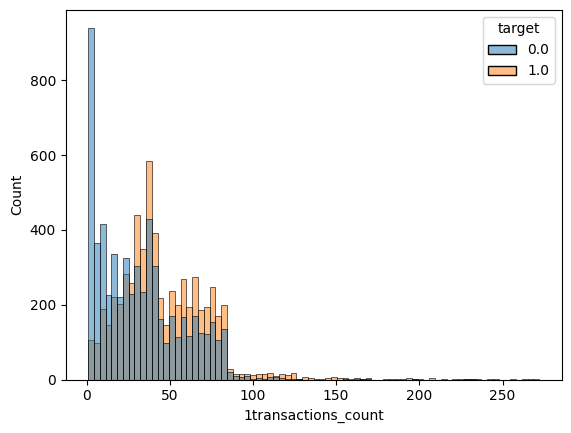

In [161]:
# look at distribution of fraudster / non fraudster by histogram for 1transactions_count
sns.histplot(data=train_res, x='1transactions_count', hue='target')

In [ ]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [ ]:
train.shape, test.shape

((135493, 11), (58069, 10))

In [ ]:
#drop redundant columns
sub_client_id = test['client_id']
drop_columns = ['client_id', 'creation_date']

for col in drop_columns:
    if col in train.columns:
        train.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation


# ******************* GOOD LUCK!!! ***************************